In [2]:
#conda activate burnseverity
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import requests
import json

import xarray as xr
import rioxarray as rxr
from rasterio.enums import Resampling
import geopandas as gpd

import validation as val



The goal of this notebook is to compare per-pixel dNBR values between our tool and the official BAER assessments for the fire where we have those. The goal is to do the following:
1. Regrid all rasters to 30 m resolution (Landsat)
2. Crop all raster to the respective CalFire boundaries to define a common domain
3. Calculate the per pixel $R^2$ 

For this analysis, our tool takes the image 15 days after the containment date to ensure comparability over fires

In [3]:
#load job list
fire_jobs = pd.read_csv("fire_processing_jobs.csv")
fire_jobs[fire_jobs['fire_name'] == 'GEOLOGY'].head(20)

baer_data_list = pd.read_csv("baer_files.csv")
baer_data_list.head()

calfire_boundaries = gpd.read_file("Validation_Fire_Perimeters_2015_2024.shp")

### Resampling
We first project both rasters to lon/lat and crop to same extend to avoid NaN values at the borders. Then we downsample the BAER raster to the resolution of the tool raster (for now.. let's discuss if this makes sense or if it should be the other way arround)

In [4]:
def make_baer_like_tool_raster(fire_name, baer_fire_list, tool_raster):

    baer_dnbr_path = baer_fire_list[baer_fire_list['fire_name'] == fire_name]['baer_dnbr_path'].values[0]

    # masked=True converts each file's own nodata value to NaN automatically
    baer_raster = rxr.open_rasterio(baer_dnbr_path, masked=True)

    baer_raster = baer_raster.rio.reproject(tool_raster.rio.crs, resampling=Resampling.average)
    baer_raster = baer_raster.rio.clip_box(*tool_raster.rio.bounds())

    baer_resampled = baer_raster.rio.reproject_match(tool_raster, resampling=Resampling.average)

    return baer_resampled


In [5]:
def raster_extent(raster):
    b = raster.rio.bounds()
    return [b[0], b[2], b[1], b[3]]  # [left, right, bottom, top] for imshow

def plot_fire_comparison(fire_name, tool_raster, baer_raster, calfire_boundary):
    """Plot 4-panel comparison (tool, BAER, anomaly, scatter) and return Pearson r."""
    boundary_reproj = calfire_boundary.to_crs(tool_raster.rio.crs)
    boundary_color = 'black'
    fig, axes = plt.subplots(1, 4, figsize=(26, 6))
    vmin, vmax = -1, 1

    tool_masked = tool_raster.where(tool_raster != -9999)

    # Tool raster
    tool_data = tool_masked.squeeze().values
    tool_ext = raster_extent(tool_raster)
    im1 = axes[0].imshow(tool_data, cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                         extent=tool_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=axes[0], color=boundary_color, linewidth=2, zorder=2)
    axes[0].set_xlim(tool_ext[0], tool_ext[1])
    axes[0].set_ylim(tool_ext[2], tool_ext[3])
    axes[0].set_title(f'Tool dNBR ({fire_name})')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    plt.colorbar(im1, ax=axes[0])

    # BAER raster
    baer_arr = baer_raster.squeeze().values
    baer_ext = raster_extent(baer_raster)
    im2 = axes[1].imshow(baer_arr, cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                         extent=baer_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=axes[1], color=boundary_color, linewidth=2, zorder=2)
    axes[1].set_xlim(baer_ext[0], baer_ext[1])
    axes[1].set_ylim(baer_ext[2], baer_ext[3])
    axes[1].set_title(f'BAER dNBR ({fire_name})')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    plt.colorbar(im2, ax=axes[1])

    # Anomaly (tool - BAER)
    anomaly = tool_masked - baer_raster
    anomaly_data = anomaly.squeeze().values
    im3 = axes[2].imshow(anomaly_data, cmap='RdBu_r', vmin=-1, vmax=1,
                         extent=tool_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=axes[2], color=boundary_color, linewidth=2, zorder=2)
    axes[2].set_xlim(tool_ext[0], tool_ext[1])
    axes[2].set_ylim(tool_ext[2], tool_ext[3])
    axes[2].set_title(f'Anomaly: Tool − BAER ({fire_name})')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    plt.colorbar(im3, ax=axes[2], extend='both')

    # Clip both rasters to the CalFire boundary before computing correlation
    tool_clipped = tool_masked.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
    baer_clipped = baer_raster.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
    valid = np.isfinite(tool_clipped) & np.isfinite(baer_clipped)
    tool_clipped = tool_clipped[valid]
    baer_clipped = baer_clipped[valid]
    correlation = float(np.corrcoef(tool_clipped, baer_clipped)[0, 1])

    axes[3].scatter(baer_clipped, tool_clipped, s=3, alpha=.5, marker='x', color='black')
    axes[3].axline((0, 0), slope=1, color='red', linewidth=1, linestyle='--', label='1:1')
    axes[3].axhline(0, color='grey', linewidth=0.8, zorder=0)
    axes[3].axvline(0, color='grey', linewidth=0.8, zorder=0)
    axes[3].set_xlim(-1, 1)
    axes[3].set_ylim(-1, 1)
    axes[3].set_aspect('equal')
    axes[3].set_xlabel('BAER dNBR')
    axes[3].set_ylabel('Tool dNBR')
    axes[3].set_title(f'{fire_name} — r = {correlation:.3f}')
    axes[3].legend()

    plt.suptitle(fire_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return correlation


### Results across all fires

Loop over all fires in `baer_files.csv`, fetch the tool result (15 days post-containment), and produce the 4-panel comparison. Fires where the tool job is not yet complete are skipped. Correlation coefficients are saved to `dnbr_correlation_results.csv`.

> **Note:** BAER dNBR is divided by 1000 to match the tool's normalised scale — this is a working assumption pending confirmation of the BAER scaling convention.


In [6]:
def compute_fire_r_squared(fire_name, date_mode, post_fire_days, fire_jobs, baer_data_list, calfire_boundaries):
    """
    Compute R² between tool dNBR and BAER dNBR for one (fire, date_mode, post_fire_days) combination.
    Returns (pearson_r, r_squared) or (np.nan, np.nan) on failure.
    """
    job_rows = fire_jobs[
        (fire_jobs['fire_name'] == fire_name) &
        (fire_jobs['date_mode'] == date_mode) &
        (fire_jobs['post_fire_days'] == post_fire_days)
    ]
    if job_rows.empty:
        return np.nan, np.nan

    fire_event_name = job_rows['fire_event_name'].values[0]
    job_id = job_rows['job_id'].values[0]

    try:
        response = requests.get(
            f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app"
            f"/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}"
        )
        response_data = response.json()
        if response_data.get('status') != 'complete':
            return np.nan, np.nan

        dnbr_url = response_data.get('coarse_severity_cog_urls', {}).get('dnbr')
        calfire_boundary = calfire_boundaries[calfire_boundaries['FIRE_NAME'] == fire_name]

        tool_raster = rxr.open_rasterio(dnbr_url)
        baer_raster = make_baer_like_tool_raster(fire_name, baer_data_list, tool_raster) / 1000

        boundary_reproj = calfire_boundary.to_crs(tool_raster.rio.crs)
        tool_masked = tool_raster.where(tool_raster != -9999)

        tool_clipped = tool_masked.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
        baer_clipped = baer_raster.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
        valid = np.isfinite(tool_clipped) & np.isfinite(baer_clipped)
        tool_clipped = tool_clipped[valid]
        baer_clipped = baer_clipped[valid]

        if len(tool_clipped) < 2:
            return np.nan, np.nan

        r = float(np.corrcoef(tool_clipped, baer_clipped)[0, 1])
        return round(r, 4), round(r ** 2, 4)

    except Exception as e:
        print(f"  {fire_name} | {date_mode} | {post_fire_days}d — ERROR: {e}")
        return np.nan, np.nan


In [6]:
POST_FIRE_DAYS = [5, 10, 15, 21, 30, 45, 60, 90]
DATE_MODES = ['alarm', 'cont']

r2_records = []

for _, baer_row in baer_data_list.iterrows():
    fire_name = baer_row['fire_name']
    print(f"Processing {fire_name}...")

    for date_mode in DATE_MODES:
        for date_after_fire in POST_FIRE_DAYS:
            r, r2 = compute_fire_r_squared(
                fire_name, date_mode, date_after_fire,
                fire_jobs, baer_data_list, calfire_boundaries
            )
            r2_records.append({
                'fire_name': fire_name,
                'date_mode': date_mode,
                'date_after_fire': date_after_fire,
                'r_squared': r2,
            })

r2_df = pd.DataFrame(r2_records)
r2_df.to_csv('dnbr_r2_results.csv', index=False)

print(f"\nSaved {len(r2_df)} rows to dnbr_r2_results.csv")
r2_df


Processing COFFEE POT...
Processing DOME...
Processing GEOLOGY...
Processing KNP Complex...
Processing MOJAVE...
Processing RATTLESNAKE...
Processing REDWOOD...
  REDWOOD | alarm | 5d — ERROR: No data found in bounds.
  REDWOOD | alarm | 10d — ERROR: No data found in bounds.
  REDWOOD | alarm | 15d — ERROR: No data found in bounds.
  REDWOOD | alarm | 21d — ERROR: No data found in bounds.
  REDWOOD | alarm | 30d — ERROR: No data found in bounds.
  REDWOOD | alarm | 45d — ERROR: No data found in bounds.
  REDWOOD | alarm | 60d — ERROR: No data found in bounds.
  REDWOOD | alarm | 90d — ERROR: No data found in bounds.
  REDWOOD | cont | 5d — ERROR: No data found in bounds.
  REDWOOD | cont | 10d — ERROR: No data found in bounds.
  REDWOOD | cont | 15d — ERROR: No data found in bounds.
  REDWOOD | cont | 21d — ERROR: No data found in bounds.
  REDWOOD | cont | 30d — ERROR: No data found in bounds.
  REDWOOD | cont | 45d — ERROR: No data found in bounds.
  REDWOOD | cont | 60d — ERROR: No 

,fire_name,date_mode,date_after_fire,r_squared
0,COFFEE POT,alarm,5,0.0005
1,COFFEE POT,alarm,10,0.0060
2,COFFEE POT,alarm,15,0.0186
3,COFFEE POT,alarm,21,0.0306
4,COFFEE POT,alarm,30,0.0467
...,...,...,...,...
155,YORK,cont,21,NaN
156,YORK,cont,30,NaN
157,YORK,cont,45,NaN
158,YORK,cont,60,NaN


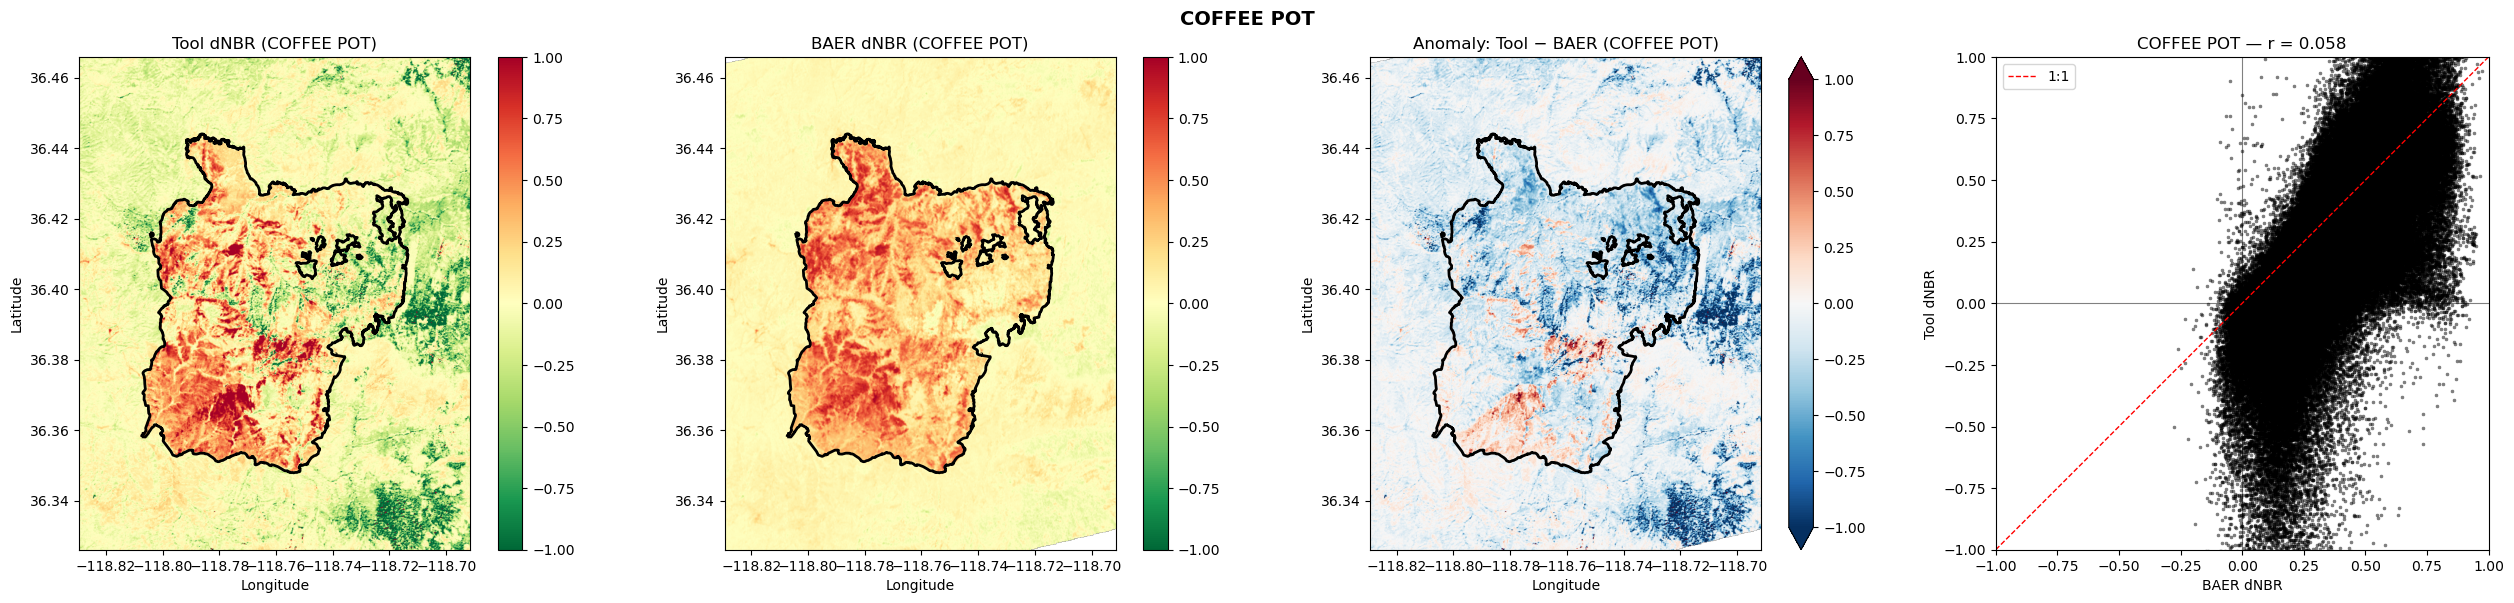

DOME: job is 'failed', skipping.


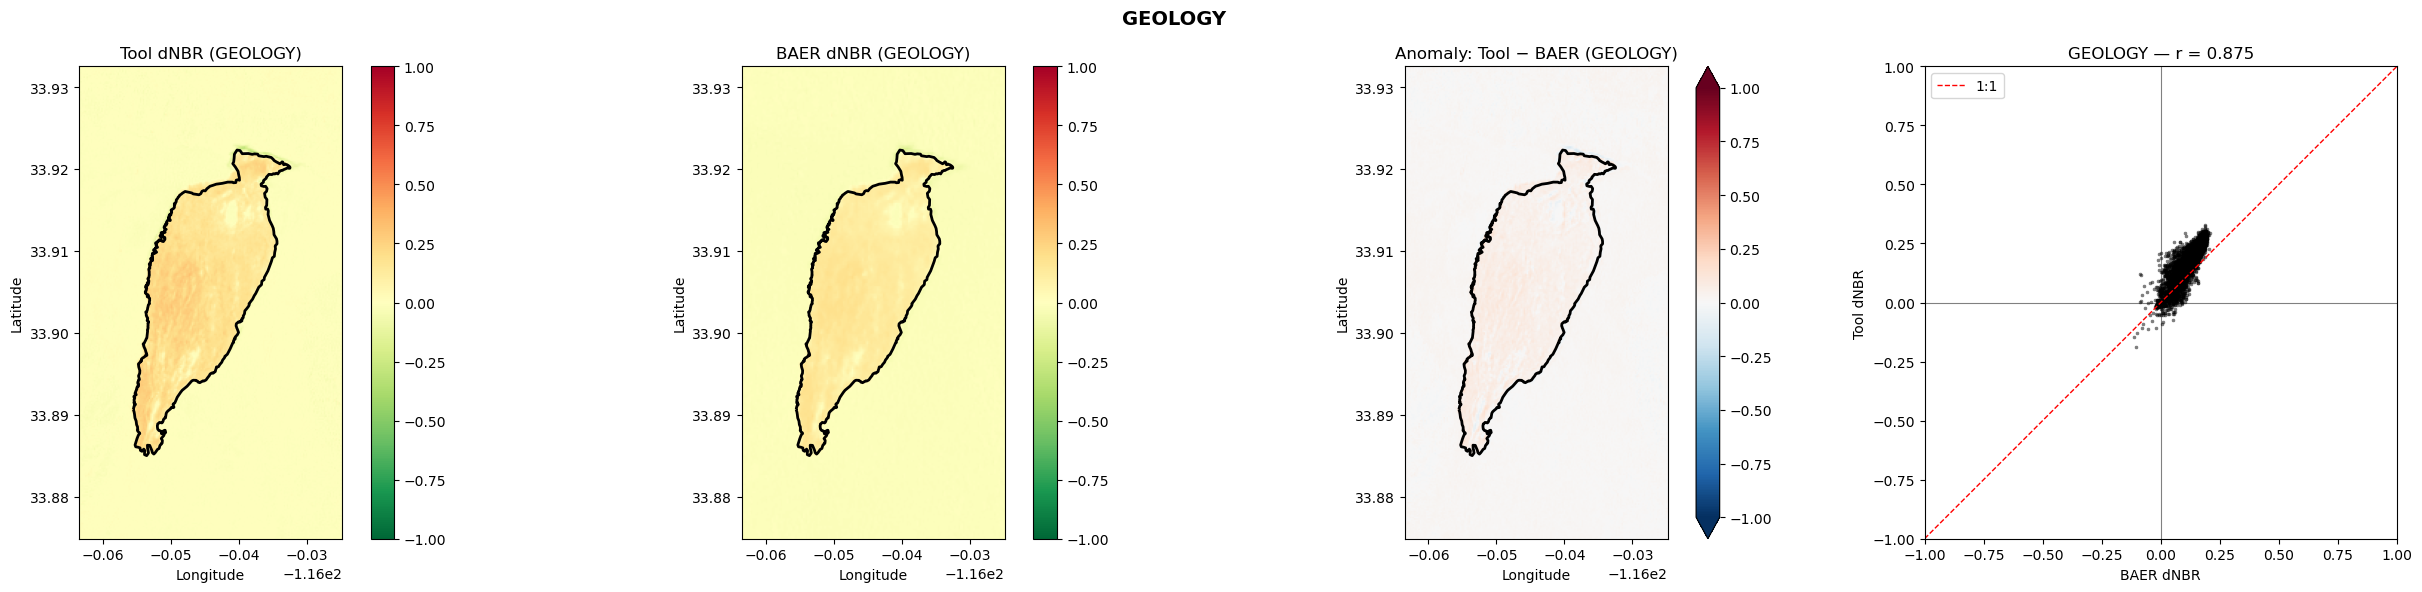

KNP Complex: job is 'pending', skipping.


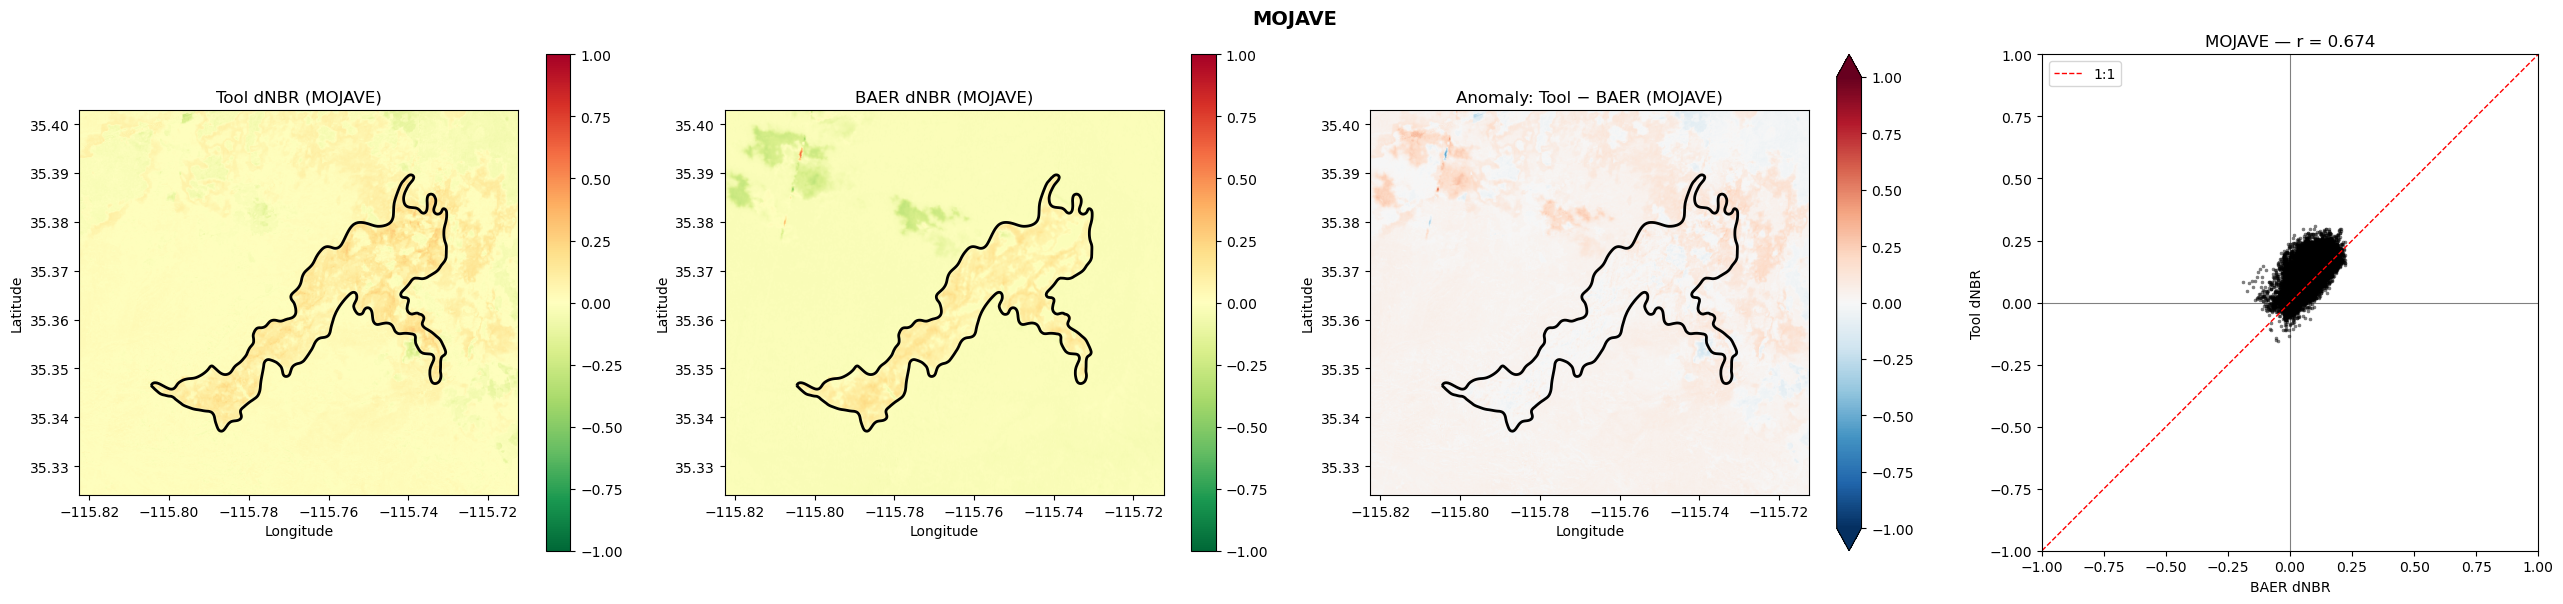

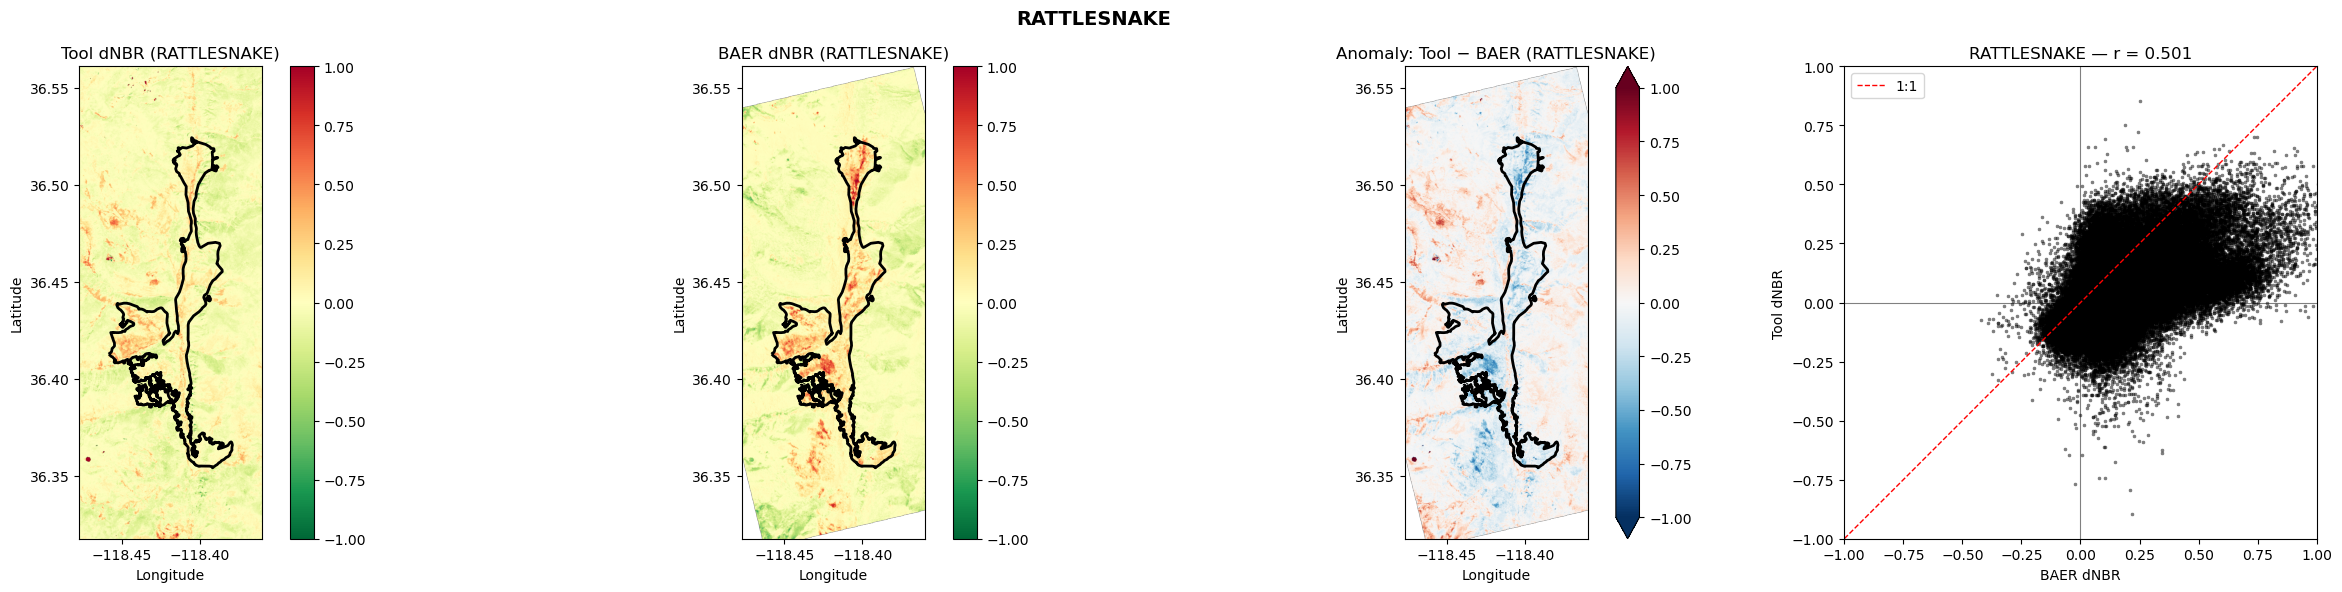


REDWOOD: ERROR — No data found in bounds.


Traceback (most recent call last):
  File "/var/folders/c4/x2rq5kz521nfv7p751bkt5c00000gn/T/ipykernel_40432/2150210836.py", line 35, in <module>
    baer_raster = make_baer_like_tool_raster(fire_name, baer_data_list, tool_raster) / 1000
                  ~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/c4/x2rq5kz521nfv7p751bkt5c00000gn/T/ipykernel_40432/2979210077.py", line 9, in make_baer_like_tool_raster
    baer_raster = baer_raster.rio.clip_box(*tool_raster.rio.bounds())
  File "/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/rioxarray/raster_array.py", line 866, in clip_box
    raise NoDataInBounds(
        f"No data found in bounds.{_get_data_var_message(self._obj)}"
    )
rioxarray.exceptions.NoDataInBounds: No data found in bounds.


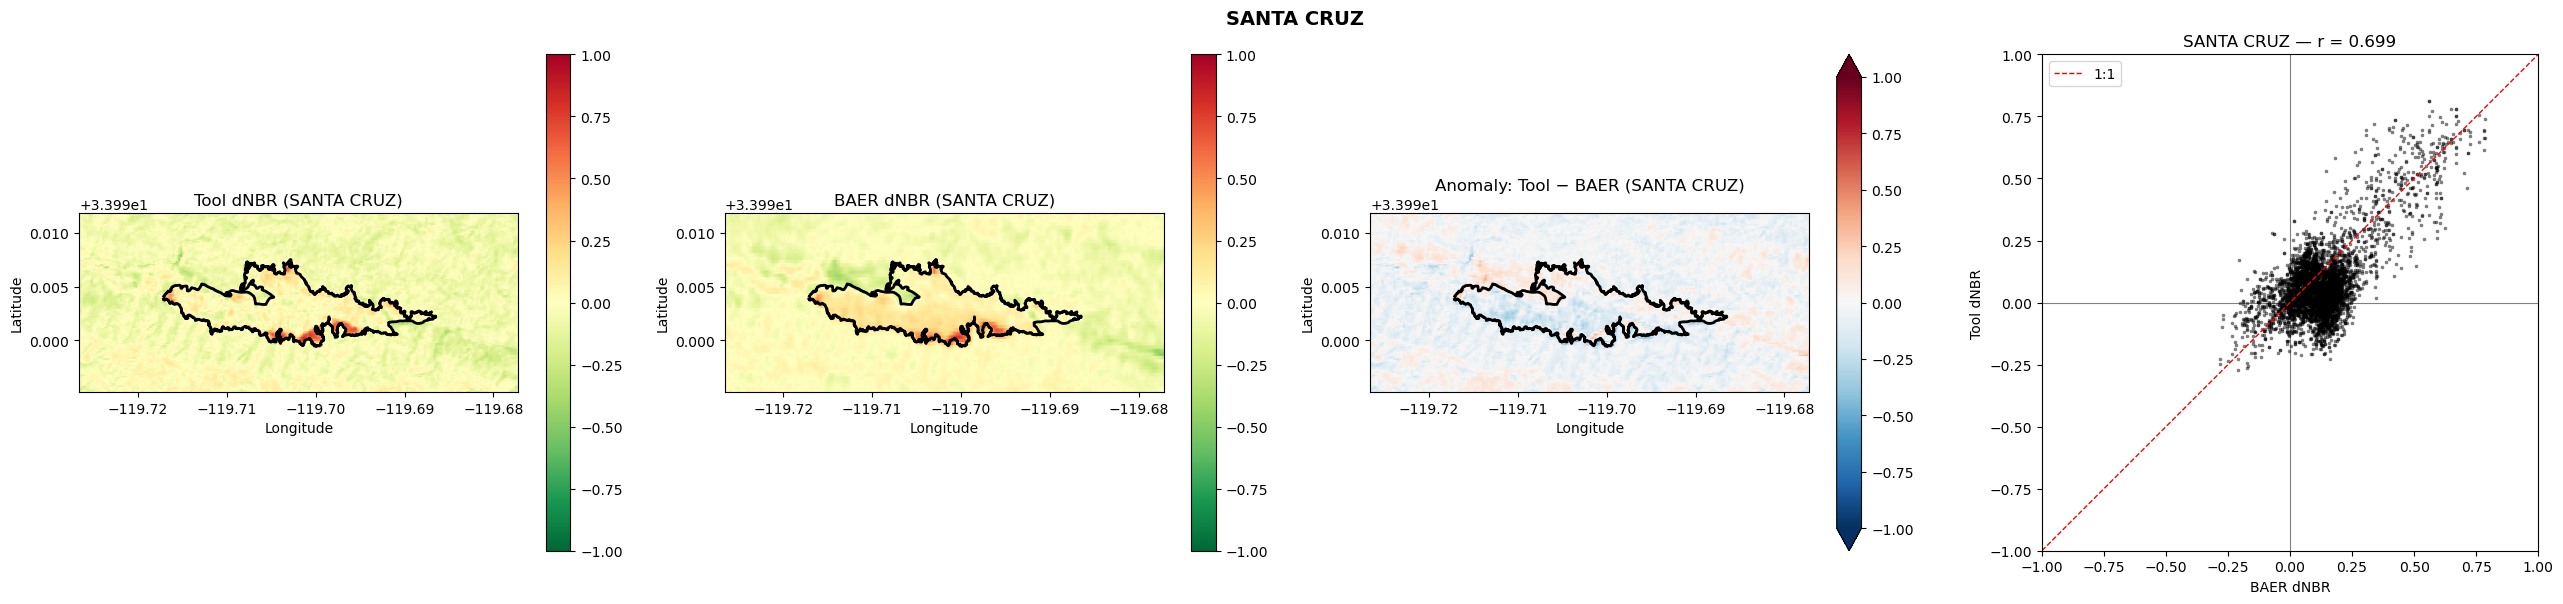

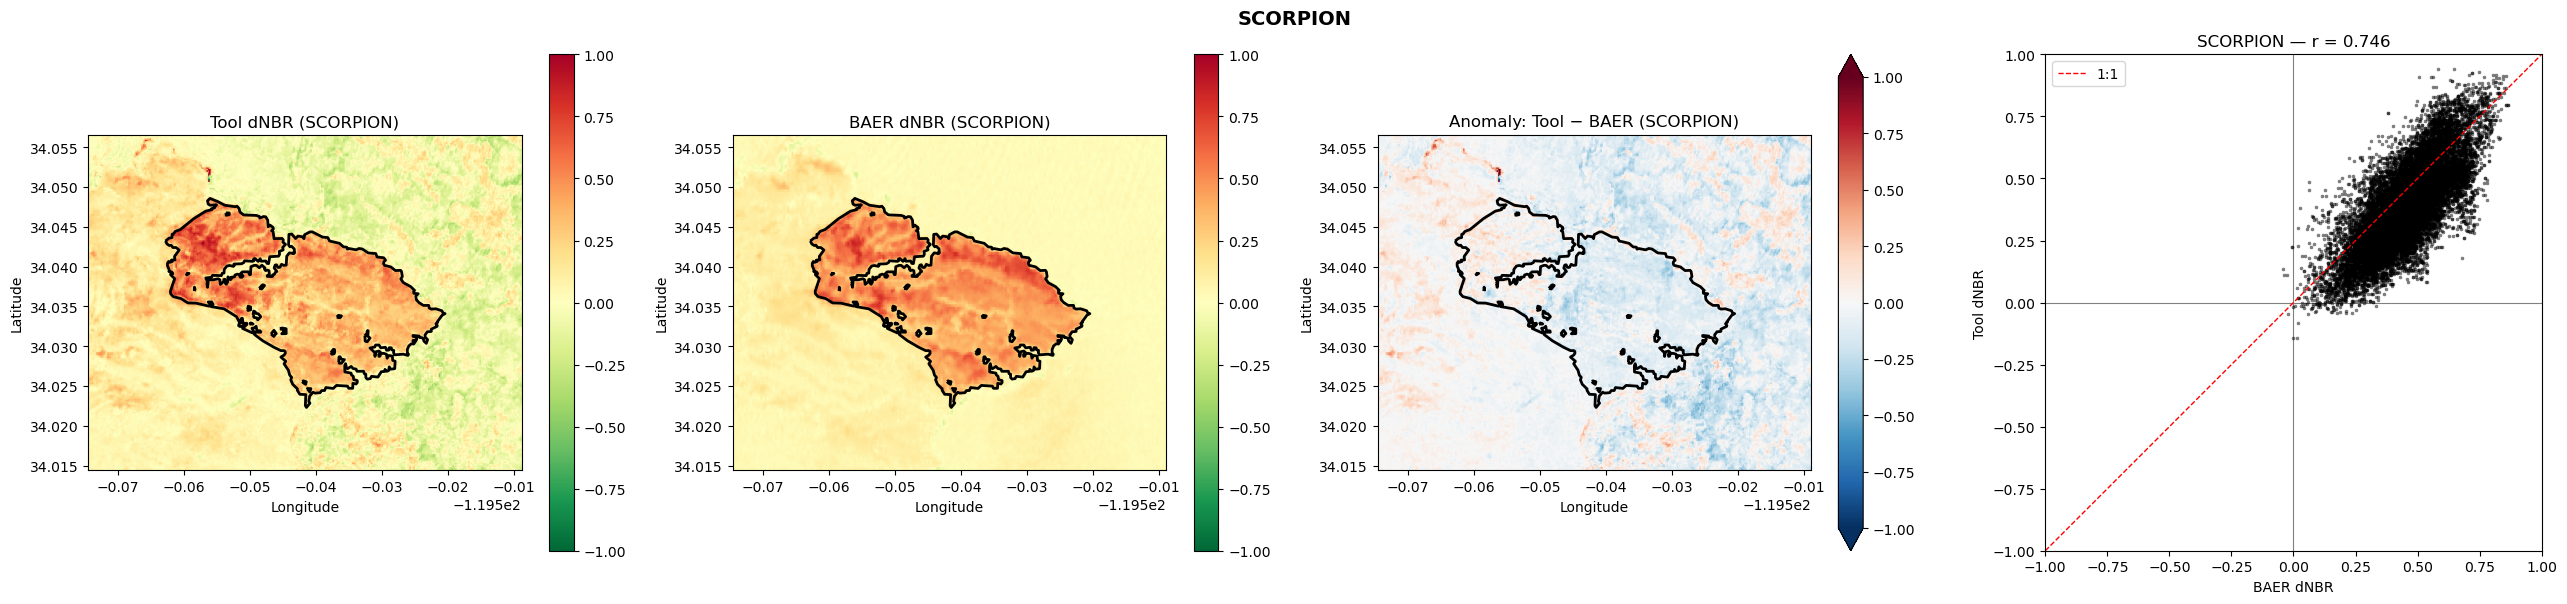

YORK: job is 'failed', skipping.


,fire_name,pearson_r
0,COFFEE POT,0.0579
1,GEOLOGY,0.8747
2,MOJAVE,0.6744
3,RATTLESNAKE,0.5008
4,SANTA CRUZ,0.6993
5,SCORPION,0.7457


In [8]:
import traceback

results = []

for _, baer_row in baer_data_list.iterrows():
    fire_name = baer_row['fire_name']

    try:
        job_rows = fire_jobs[
            (fire_jobs['fire_name'] == fire_name) &
            (fire_jobs['date_mode'] == 'alarm') &
            (fire_jobs['post_fire_days'] == 60)
        ]
        if job_rows.empty:
            print(f"{fire_name}: no matching job found, skipping.")
            continue

        fire_event_name = job_rows['fire_event_name'].values[0]
        job_id = job_rows['job_id'].values[0]

        response = requests.get(
            f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app"
            f"/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}"
        )
        response_data = response.json()

        if response_data.get('status') != 'complete':
            print(f"{fire_name}: job is '{response_data.get('status')}', skipping.")
            continue

        dnbr_url = response_data.get('coarse_severity_cog_urls', {}).get('dnbr')
        calfire_boundary = calfire_boundaries[calfire_boundaries['FIRE_NAME'] == fire_name]

        tool_raster = rxr.open_rasterio(dnbr_url)
        baer_raster = make_baer_like_tool_raster(fire_name, baer_data_list, tool_raster) / 1000

        correlation = plot_fire_comparison(fire_name, tool_raster, baer_raster, calfire_boundary)
        results.append({'fire_name': fire_name, 'pearson_r': round(correlation, 4)})

    except Exception as e:
        print(f"\n{fire_name}: ERROR — {e}")
        traceback.print_exc()
        continue

results_df = pd.DataFrame(results)
results_df.to_csv('dnbr_correlation_results.csv', index=False)
results_df


### Spotlight: Geology, Mojave & Scorpion

Side-by-side comparison for the three low-signal fires on a shared ±0.75 scale.
Columns: RBR (tool) · dNBR (tool) · dNBR (BAER) · Anomaly (tool dNBR − BAER).

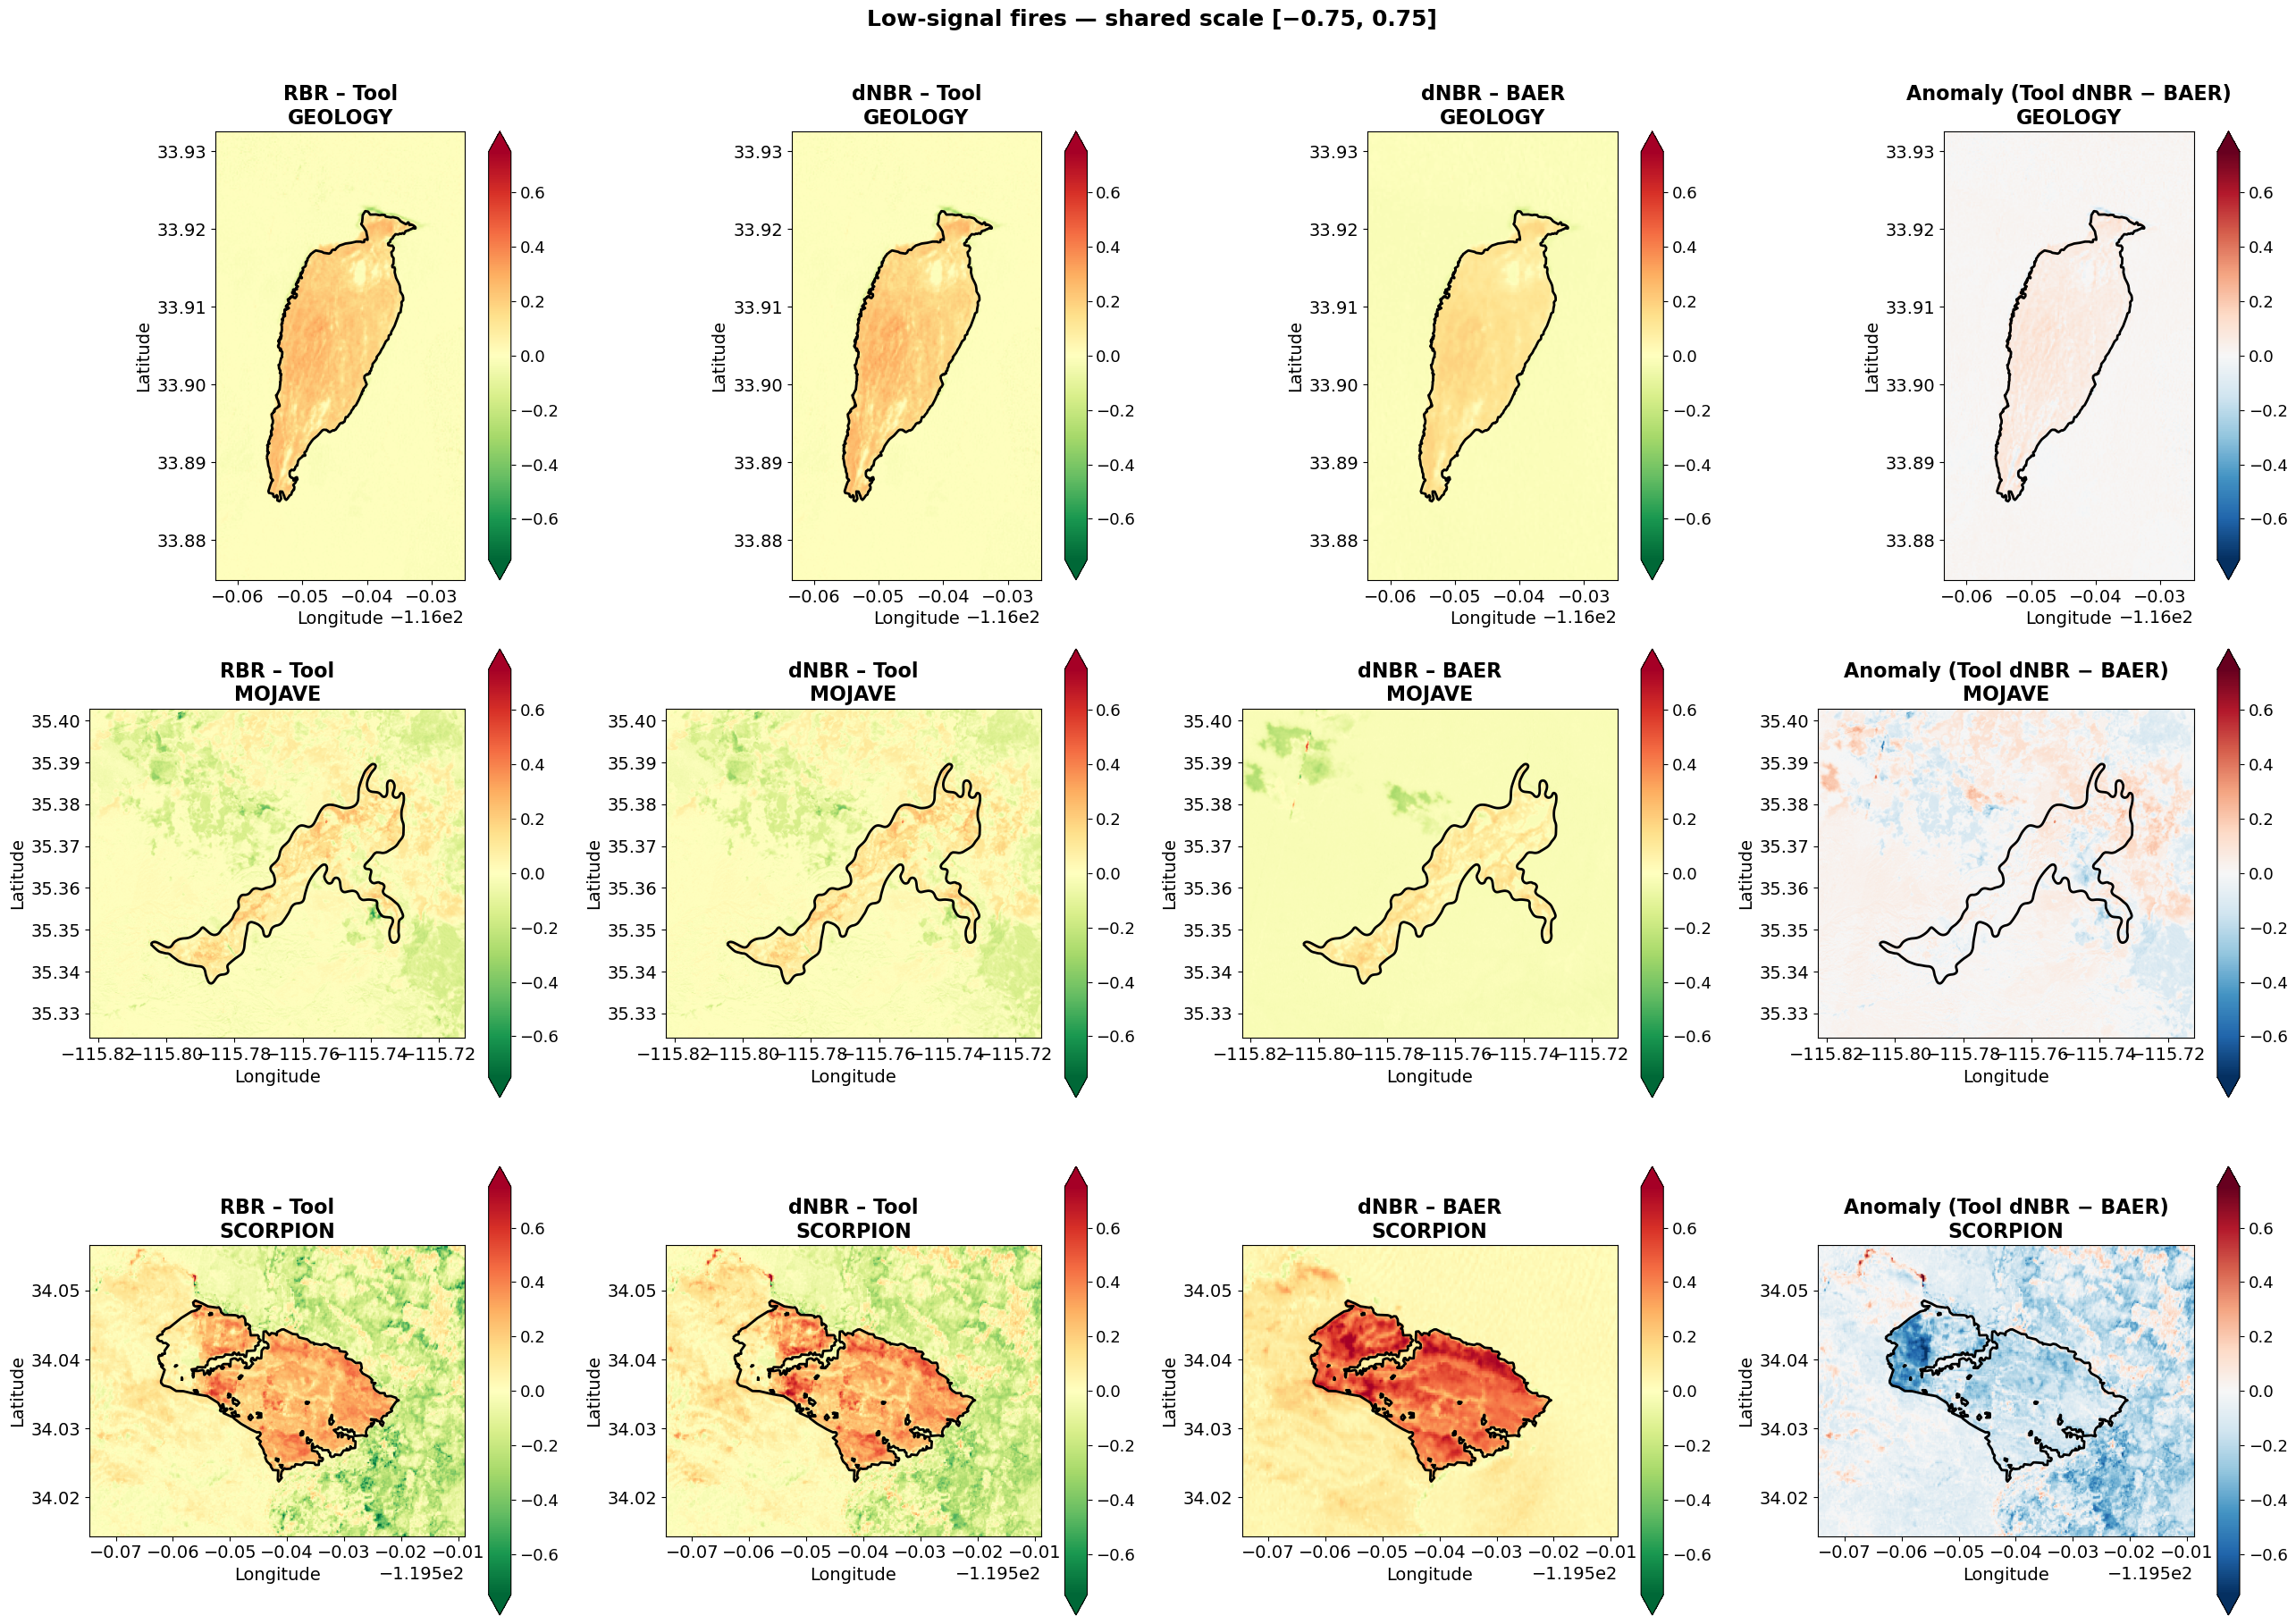

In [8]:

SPOTLIGHT_FIRES = ['GEOLOGY', 'MOJAVE', 'SCORPION']
VMIN, VMAX = -0.75, 0.75
FONT_SIZE = 14
TITLE_SIZE = 16

plt.rcParams.update({'font.size': FONT_SIZE})

fig, axes = plt.subplots(3, 4, figsize=(26, 18))

for row_idx, fire_name in enumerate(SPOTLIGHT_FIRES):
    job_rows = fire_jobs[
        (fire_jobs['fire_name'] == fire_name) &
        (fire_jobs['date_mode'] == 'alarm') &
        (fire_jobs['post_fire_days'] == 21)
    ]
    if job_rows.empty:
        print(f"{fire_name}: no matching job, skipping.")
        continue

    fire_event_name = job_rows['fire_event_name'].values[0]
    job_id = job_rows['job_id'].values[0]

    response = requests.get(
        f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app"
        f"/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}"
    )
    response_data = response.json()
    if response_data.get('status') != 'complete':
        print(f"{fire_name}: job not complete, skipping.")
        continue

    urls = response_data.get('coarse_severity_cog_urls', {})
    dnbr_url = urls.get('dnbr')
    rbr_url  = urls.get('rbr')

    dnbr_raster = rxr.open_rasterio(dnbr_url)
    rbr_raster  = rxr.open_rasterio(rbr_url)
    baer_raster = make_baer_like_tool_raster(fire_name, baer_data_list, dnbr_raster) / 1000

    calfire_boundary = calfire_boundaries[calfire_boundaries['FIRE_NAME'] == fire_name]
    boundary_reproj  = calfire_boundary.to_crs(dnbr_raster.rio.crs)
    boundary_color   = 'black'

    dnbr_masked = dnbr_raster.where(dnbr_raster != -9999)
    rbr_masked  = rbr_raster.where(rbr_raster != -9999)

    dnbr_ext = raster_extent(dnbr_raster)
    rbr_ext  = raster_extent(rbr_raster)
    baer_ext = raster_extent(baer_raster)

    cmap_sev = 'RdYlGn_r'
    cmap_ano = 'RdBu_r'

    # --- Col 0: RBR tool ---
    ax = axes[row_idx, 0]
    im = ax.imshow(rbr_masked.squeeze().values, cmap=cmap_sev,
                   vmin=VMIN, vmax=VMAX, extent=rbr_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(rbr_ext[0], rbr_ext[1]); ax.set_ylim(rbr_ext[2], rbr_ext[3])
    ax.set_title(f'RBR – Tool\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE)
    ax.set_ylabel('Latitude',  fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

    # --- Col 1: dNBR tool ---
    ax = axes[row_idx, 1]
    im = ax.imshow(dnbr_masked.squeeze().values, cmap=cmap_sev,
                   vmin=VMIN, vmax=VMAX, extent=dnbr_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(dnbr_ext[0], dnbr_ext[1]); ax.set_ylim(dnbr_ext[2], dnbr_ext[3])
    ax.set_title(f'dNBR – Tool\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE)
    ax.set_ylabel('Latitude',  fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

    # --- Col 2: dNBR BAER ---
    ax = axes[row_idx, 2]
    im = ax.imshow(baer_raster.squeeze().values, cmap=cmap_sev,
                   vmin=VMIN, vmax=VMAX, extent=baer_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(baer_ext[0], baer_ext[1]); ax.set_ylim(baer_ext[2], baer_ext[3])
    ax.set_title(f'dNBR – BAER\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE)
    ax.set_ylabel('Latitude',  fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

    # --- Col 3: Anomaly (tool dNBR − BAER) ---
    anomaly = dnbr_masked - baer_raster
    ax = axes[row_idx, 3]
    im = ax.imshow(anomaly.squeeze().values, cmap=cmap_ano,
                   vmin=VMIN, vmax=VMAX, extent=dnbr_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(dnbr_ext[0], dnbr_ext[1]); ax.set_ylim(dnbr_ext[2], dnbr_ext[3])
    ax.set_title(f'Anomaly (Tool dNBR − BAER)\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE)
    ax.set_ylabel('Latitude',  fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

plt.suptitle('Low-signal fires — shared scale [−0.75, 0.75]', fontsize=TITLE_SIZE + 2, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Restore default font size
plt.rcParams.update({'font.size': plt.rcParamsDefault['font.size']})


### All fires — 5-panel comparison

5 columns per fire row: **RBR (tool)** · **dNBR (tool)** · **dNBR (BAER)** · **Anomaly (tool − BAER)** · **Scatter / R²**.  
Fires DOME, REDWOOD, and YORK are excluded. Scale is determined automatically from the 99th percentile of all loaded data so it stays as tight as possible.

In [ ]:
SKIP_FIRES = {'YORK', 'DOME', 'REDWOOD'}
DATE_MODE = 'alarm'
POST_FIRE_DAYS = 21

fires_to_plot = baer_data_list[~baer_data_list['fire_name'].isin(SKIP_FIRES)]

FONT_SIZE = 13
TITLE_SIZE = 14
cmap_sev = 'RdYlGn_r'
cmap_ano = 'RdBu_r'
boundary_color = 'black'

# --- Pass 1: fetch all rasters and collect values for scale estimation ---
fire_data = []
all_values = []

for _, baer_row in fires_to_plot.iterrows():
    fire_name = baer_row['fire_name']

    job_rows = fire_jobs[
        (fire_jobs['fire_name'] == fire_name) &
        (fire_jobs['date_mode'] == DATE_MODE) &
        (fire_jobs['post_fire_days'] == POST_FIRE_DAYS)
    ]
    if job_rows.empty:
        print(f"{fire_name}: no matching job ({DATE_MODE}, +{POST_FIRE_DAYS}d), skipping.")
        continue

    fire_event_name = job_rows['fire_event_name'].values[0]
    job_id = job_rows['job_id'].values[0]

    try:
        resp = requests.get(
            f"https://fire-recovery-backend-dev-113009620257.us-central1.run.app"
            f"/fire-recovery/result/analyze_fire_severity/{fire_event_name}/{job_id}"
        )
        resp_data = resp.json()
        if resp_data.get('status') != 'complete':
            print(f"{fire_name}: job is '{resp_data.get('status')}', skipping.")
            continue

        urls = resp_data.get('coarse_severity_cog_urls', {})
        dnbr_raster = rxr.open_rasterio(urls['dnbr'])
        rbr_raster  = rxr.open_rasterio(urls['rbr'])
        baer_raster = make_baer_like_tool_raster(fire_name, baer_data_list, dnbr_raster) / 1000

        calfire_boundary = calfire_boundaries[calfire_boundaries['FIRE_NAME'] == fire_name]
        boundary_reproj  = calfire_boundary.to_crs(dnbr_raster.rio.crs)

        dnbr_masked = dnbr_raster.where(dnbr_raster != -9999)
        rbr_masked  = rbr_raster.where(rbr_raster != -9999)

        for arr in [dnbr_masked.values, rbr_masked.values, baer_raster.values]:
            flat = arr.ravel()
            all_values.extend(flat[np.isfinite(flat)].tolist())

        fire_data.append((fire_name, dnbr_masked, rbr_masked, baer_raster, boundary_reproj))
        print(f"{fire_name}: loaded.")

    except Exception as e:
        import traceback
        print(f"{fire_name}: ERROR — {e}")
        traceback.print_exc()

# --- Determine tight shared scale from 99th percentile of absolute values ---
all_values = np.array(all_values)
vmax_raw = float(np.nanpercentile(np.abs(all_values), 99))
# Round up to nearest 0.05 for clean tick labels
VMAX = np.ceil(vmax_raw / 0.05) * 0.05
VMIN = -VMAX
print(f"\nAuto-scale: [{VMIN:.2f}, {VMAX:.2f}]  (99th-pct abs = {vmax_raw:.3f})")

# --- Pass 2: plot ---
n_fires = len(fire_data)
plt.rcParams.update({'font.size': FONT_SIZE})

fig, axes = plt.subplots(n_fires, 5, figsize=(34, 6 * n_fires))
if n_fires == 1:
    axes = axes[np.newaxis, :]

for row_idx, (fire_name, dnbr_masked, rbr_masked, baer_raster, boundary_reproj) in enumerate(fire_data):
    dnbr_ext = raster_extent(dnbr_masked)
    rbr_ext  = raster_extent(rbr_masked)
    baer_ext = raster_extent(baer_raster)

    # Col 0: RBR – Tool
    ax = axes[row_idx, 0]
    im = ax.imshow(rbr_masked.squeeze().values, cmap=cmap_sev,
                   vmin=VMIN, vmax=VMAX, extent=rbr_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(rbr_ext[0], rbr_ext[1]); ax.set_ylim(rbr_ext[2], rbr_ext[3])
    ax.set_title(f'RBR – Tool\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE); ax.set_ylabel('Latitude', fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

    # Col 1: dNBR – Tool
    ax = axes[row_idx, 1]
    im = ax.imshow(dnbr_masked.squeeze().values, cmap=cmap_sev,
                   vmin=VMIN, vmax=VMAX, extent=dnbr_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(dnbr_ext[0], dnbr_ext[1]); ax.set_ylim(dnbr_ext[2], dnbr_ext[3])
    ax.set_title(f'dNBR – Tool\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE); ax.set_ylabel('Latitude', fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

    # Col 2: dNBR – BAER
    ax = axes[row_idx, 2]
    im = ax.imshow(baer_raster.squeeze().values, cmap=cmap_sev,
                   vmin=VMIN, vmax=VMAX, extent=baer_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(baer_ext[0], baer_ext[1]); ax.set_ylim(baer_ext[2], baer_ext[3])
    ax.set_title(f'dNBR – BAER\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE); ax.set_ylabel('Latitude', fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

    # Col 3: Anomaly (Tool dNBR − BAER)
    anomaly = dnbr_masked - baer_raster
    ax = axes[row_idx, 3]
    im = ax.imshow(anomaly.squeeze().values, cmap=cmap_ano,
                   vmin=VMIN, vmax=VMAX, extent=dnbr_ext, origin='upper', zorder=1)
    boundary_reproj.boundary.plot(ax=ax, color=boundary_color, linewidth=2, zorder=2)
    ax.set_xlim(dnbr_ext[0], dnbr_ext[1]); ax.set_ylim(dnbr_ext[2], dnbr_ext[3])
    ax.set_title(f'Anomaly (Tool − BAER)\n{fire_name}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE); ax.set_ylabel('Latitude', fontsize=FONT_SIZE)
    plt.colorbar(im, ax=ax, extend='both').ax.tick_params(labelsize=FONT_SIZE - 1)

    # Col 4: Scatter / R²
    tool_clip = dnbr_masked.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
    baer_clip = baer_raster.rio.clip(boundary_reproj.geometry, drop=True).squeeze().values.ravel()
    valid = np.isfinite(tool_clip) & np.isfinite(baer_clip)
    tool_clip = tool_clip[valid]
    baer_clip = baer_clip[valid]
    if len(tool_clip) >= 2:
        r  = float(np.corrcoef(tool_clip, baer_clip)[0, 1])
        r2 = r ** 2
    else:
        r = r2 = np.nan

    ax = axes[row_idx, 4]
    ax.scatter(baer_clip, tool_clip, s=2, alpha=0.3, marker='.', color='black', rasterized=True)
    ax.axline((0, 0), slope=1, color='red', linewidth=1, linestyle='--', label='1:1')
    ax.axhline(0, color='grey', linewidth=0.6, zorder=0)
    ax.axvline(0, color='grey', linewidth=0.6, zorder=0)
    ax.set_xlim(VMIN, VMAX); ax.set_ylim(VMIN, VMAX)
    ax.set_aspect('equal')
    ax.set_xlabel('BAER dNBR', fontsize=FONT_SIZE)
    ax.set_ylabel('Tool dNBR', fontsize=FONT_SIZE)
    ax.set_title(f'Scatter\n{fire_name}  r={r:.3f}  R²={r2:.3f}', fontsize=TITLE_SIZE, fontweight='bold')
    ax.legend(fontsize=FONT_SIZE - 2)

plt.suptitle(
    f'All fires — shared scale [{VMIN:.2f}, {VMAX:.2f}]  (date_mode={DATE_MODE}, +{POST_FIRE_DAYS} days)',
    fontsize=TITLE_SIZE + 3, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('all_fires_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

plt.rcParams.update({'font.size': plt.rcParamsDefault['font.size']})

COFFEE POT: loaded.
GEOLOGY: loaded.
KNP Complex: job is 'failed', skipping.
MOJAVE: loaded.
RATTLESNAKE: loaded.
SANTA CRUZ: loaded.
SCORPION: loaded.

Auto-scale: [-0.60, 0.60]  (99th-pct abs = 0.555)
